# Notebook 4 — Machine Learning Pipeline (Valence)

**Objective.** Train and compare three classifiers that predict the
**valence** label (`negative` / `neutral` / `positive`) from the **plant bioelectric features**
of each 30-second window, and identify the best-performing model.

This notebook mirrors `04_ml_pipeline_emotion.ipynb`, which predicts the
crossed `label` (5 classes). Here the target is instead **`valence_direction`** —
one of the two independent axes produced by `02_emotion_labelling_v03.ipynb`
(see its §4.8). The other axis, the crossed `label`, and every HRV/FER
column are **excluded from the features** — the model sees **only the plant
signal**, nothing derived from heart rate or the face.

**Models compared**
1. **Random Forest** (bagged decision trees)
2. **XGBoost** (gradient-boosted trees)
3. **Neural Network** (multi-layer perceptron)

**Pipeline overview**
1. Load the consolidated dataset (output of Notebook 1 / `03_dataset_creation.ipynb`)
2. Select plant-only features (spreadsheet-style plant columns, no HRV/FER, no `label_confidence`)
3. Clean: handle missing values, encode categoricals, drop redundant columns
4. Split into train / validation / test **without participant leakage**
5. Scale features
6. Hyperparameter tuning via **Randomised Search** (per model)
7. Evaluate: accuracy, F1, ROC-AUC, confusion matrix, classification report
8. Compare models, inspect feature importance, discuss findings

> **Note on dataset size.** This is an exploratory study (N ≈ 10–15
> participants). The absolute scores matter less than the *relative* comparison
> of the three approaches and the methodology, which is built to scale to a
> larger cohort without changes.


## 1  Imports & Configuration

We fix a global `RANDOM_STATE` for full reproducibility. XGBoost is optional —
if it is not installed the notebook still runs the other two models and says so.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, GroupShuffleSplit
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

try:
    from xgboost import XGBClassifier
    XGBOOST_OK = True
except ImportError:
    XGBOOST_OK = False
    print("xgboost not installed — pip install xgboost (XGBoost model will be skipped)")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

TARGET_COL = "valence_direction"   # the axis this notebook predicts

DATASET_CSV = Path("../data/datasets/consolidated_dataset.csv")   # output of Notebook 1
print(f"Dataset: {DATASET_CSV.resolve()}")
print(f"Target column: {TARGET_COL}")
print(f"XGBoost available: {XGBOOST_OK}")


Dataset: C:\Uni Koeln\COIN_Project\COIN2026_Team-1_Plant-Emotion-Detector\data\datasets\consolidated_dataset.csv
Target column: valence_direction
XGBoost available: True


## 2  Load the Consolidated Dataset

We load the single CSV produced by Notebook 1 and take a first look at its
shape, columns and the class balance of the target (`valence_direction`).


In [2]:
df = pd.read_csv(DATASET_CSV)
print(f"Loaded {df.shape[0]} rows x {df.shape[1]} columns\n")
print("Target (valence_direction) distribution:")
print(df[TARGET_COL].value_counts().to_string())
print("\nClass balance:")
print(df[TARGET_COL].value_counts(normalize=True).mul(100).round(1).astype(str).add(' %').to_string())
df.head()


Loaded 284 rows x 50 columns

Target (valence_direction) distribution:
valence_direction
neutral     105
negative     96
positive     83

Class balance:
valence_direction
neutral     37.0 %
negative    33.8 %
positive    29.2 %


,session_id,participant_id,session_date,win_start_ms,win_end_ms,label,valence_direction,arousal_level,label_confidence,reason,...,plant_sat_neg_frac,plant_const_flag,bp_0_1,bp_1_5,bp_5_15,bp_15_30,band_power_sum,plant_quality,plant_dead_flag,plant_suspect_flag
0,2026-07-06_16-11_proband_01,proband_01,2026-07-06,1783347110256,1783347140256,positive calm,positive,calm,0.903,clear,...,0.0,False,0.000129,0.000010,0.000013,0.000011,0.000163,ok,False,False
1,2026-07-06_16-11_proband_01,proband_01,2026-07-06,1783347140256,1783347170256,neutral,positive,neutral,0.786,hrv_ambiguous,...,0.0,False,0.000091,0.000012,0.000015,0.000013,0.000131,ok,False,False
2,2026-07-06_16-11_proband_01,proband_01,2026-07-06,1783347170256,1783347200256,positive activated,positive,activated,0.881,clear,...,0.0,False,0.000041,0.000012,0.000015,0.000015,0.000083,ok,False,False
3,2026-07-06_16-11_proband_01,proband_01,2026-07-06,1783347200256,1783347230256,negative calm,negative,calm,0.907,clear,...,0.0,False,0.000118,0.000012,0.000013,0.000014,0.000157,ok,False,False
4,2026-07-06_16-11_proband_01,proband_01,2026-07-06,1783347230256,1783347260256,neutral,negative,neutral,0.883,hrv_ambiguous,...,0.0,False,0.000076,0.000012,0.000016,0.000014,0.000118,ok,False,False


## 3  Feature Selection & Inspection

### Target
The prediction target is **`valence_direction`** (`negative` / `neutral` / `positive`), one of the two
independent axes described in `02_emotion_labelling_v03.ipynb` §4.6-4.8.

### Candidate features — plant signal only
Per the task for this notebook, features are **restricted to the
plant-voltage columns** — no `label_confidence`, no HRV, no facial-expression
columns. This is a stricter cut than `04_ml_pipeline_emotion.ipynb`, which
also fed in `label_confidence`:

| Feature group | Columns |
|---|---|
| Central tendency / spread | `plant_mean`, `plant_median`, `plant_std`, `plant_iqr`, `plant_min`, `plant_max`, `plant_range`, `plant_rms`, `plant_zcr` |
| Saturation / constancy | `plant_sat_pos_frac`, `plant_sat_neg_frac`, `plant_const_flag` |
| Spectral band powers | `bp_0_1`, `bp_1_5`, `bp_5_15`, `bp_15_30`, `band_power_sum` |
| Quality flags | `plant_quality`, `plant_dead_flag`, `plant_suspect_flag` |

### Why *not* the HRV/FER columns, `label_confidence`, the other axis, or `label`?
- `rmssd`, `mean_hr`, `arousal_hrv`, `fer_valence`, `fer_arousal`, … are
  exactly the signals `valence_direction` was *derived from* (§4.7-4.8 of the
  labelling notebook). Feeding them back as predictors would be **target
  leakage**.
- `label_confidence` is a weighted blend of *both* axes' clarity (§4.8, step
  5) — including it would leak information about how far this window sits
  from its valence deadband, which is exactly what the model should be
  learning to predict from the plant signal instead.
- The **other axis** and the crossed `label` are excluded for the same
  reason: `label` is a deterministic function of `valence_direction` and
  `arousal_level`, so either would leak the target through the back door.

We restrict predictors to the plant features and inspect each candidate for
usefulness before committing.


In [3]:
# Define the candidate feature columns — plant-only, no label_confidence,
# no HRV/FER, no other axis, no crossed label.
plant_features = [
    "plant_mean", "plant_median", "plant_std", "plant_iqr",
    "plant_min", "plant_max", "plant_range", "plant_rms", "plant_zcr",
    "plant_sat_pos_frac", "plant_sat_neg_frac", "plant_const_flag",
    "bp_0_1", "bp_1_5", "bp_5_15", "bp_15_30", "band_power_sum",
    "plant_quality", "plant_dead_flag", "plant_suspect_flag",
]
candidate_features = plant_features

# Keep only those actually present (robust to schema variations)
candidate_features = [c for c in candidate_features if c in df.columns]
print(f"{len(candidate_features)} candidate features present.\n")

# Inspect dtypes, missingness and variance
inspect = pd.DataFrame({
    "dtype":     df[candidate_features].dtypes.astype(str),
    "n_missing": df[candidate_features].isna().sum(),
    "n_unique":  df[candidate_features].nunique(),
})
print(inspect.to_string())


20 candidate features present.

                      dtype  n_missing  n_unique
plant_mean          float64          0       250
plant_median        float64          0       259
plant_std           float64          0       275
plant_iqr           float64          0       279
plant_min           float64          0       283
plant_max           float64          0       283
plant_range         float64          0       284
plant_rms           float64          0       262
plant_zcr           float64          0       283
plant_sat_pos_frac  float64          0         1
plant_sat_neg_frac  float64          0         1
plant_const_flag       bool          0         1
bp_0_1              float64          0       284
bp_1_5              float64          0       284
bp_5_15             float64          0       284
bp_15_30            float64          0       284
band_power_sum      float64          0       284
plant_quality        object          0         2
plant_dead_flag        bool          

### Removing redundant / non-informative features

We drop features that cannot help the model:

- **Constant columns** (`n_unique == 1`) carry no information. In a clean
  recording `plant_const_flag` is always `False` and `plant_sat_*` are 0 — if
  so they are dropped automatically.
- **`plant_quality`** is a categorical *summary* of `plant_std` / saturation; we
  keep the boolean `plant_dead_flag` / `plant_suspect_flag` instead (cleaner for
  modelling) and one-hot `plant_quality` only if it varies.
- **`plant_n_samples`** is a coverage/QA field, not a physiological signal —
  dropped if near-constant.

This is done data-driven below, so it adapts to whatever the real recordings
contain.


In [4]:
# Drop constant candidate features (no information)
nunique = df[candidate_features].nunique()
constant_cols = nunique[nunique <= 1].index.tolist()
if constant_cols:
    print(f"Dropping {len(constant_cols)} constant feature(s): {constant_cols}")
candidate_features = [c for c in candidate_features if c not in constant_cols]

# plant_n_samples: drop if near-constant (coverage QA, not signal)
if "plant_n_samples" in df.columns and df["plant_n_samples"].std() < 1e-6:
    if "plant_n_samples" in candidate_features:
        candidate_features.remove("plant_n_samples")
        print("Dropping 'plant_n_samples' (near-constant coverage field).")

print(f"\n{len(candidate_features)} features remain after redundancy removal:")
print(candidate_features)


Dropping 4 constant feature(s): ['plant_sat_pos_frac', 'plant_sat_neg_frac', 'plant_const_flag', 'plant_dead_flag']

16 features remain after redundancy removal:
['plant_mean', 'plant_median', 'plant_std', 'plant_iqr', 'plant_min', 'plant_max', 'plant_range', 'plant_rms', 'plant_zcr', 'bp_0_1', 'bp_1_5', 'bp_5_15', 'bp_15_30', 'band_power_sum', 'plant_quality', 'plant_suspect_flag']


## 4  Preprocessing: Missing Values & Encoding

**Missing values.** Spectral features can be `NaN` for windows that were too
short or flat for a Welch PSD, or where the plant merge produced no reading
for a session. We:
- drop rows whose target (`valence_direction`) is missing or `"excluded"`,
- impute remaining numeric `NaN`s with the **median** (robust to outliers).

**Categorical encoding.** `plant_quality` (if kept) is one-hot encoded. Boolean
flags are cast to integers (0/1).

**Quality filtering.** Windows flagged `plant_dead_flag` are electrode-failure
artefacts with no usable plant signal; we drop them from the modelling set
(kept configurable).


In [5]:
DROP_DEAD_WINDOWS = True   # exclude electrode-failure windows from modelling

work = df.copy()

# 1) Drop rows with missing or excluded target
work = work.dropna(subset=[TARGET_COL]).reset_index(drop=True)
work = work[work[TARGET_COL] != "excluded"].reset_index(drop=True)

# 2) Optionally drop dead-electrode windows
if DROP_DEAD_WINDOWS and "plant_dead_flag" in work.columns:
    before = len(work)
    # plant_dead_flag may be bool or string "True"/"False"
    dead = work["plant_dead_flag"].astype(str).str.lower().isin(["true", "1"])
    work = work[~dead].reset_index(drop=True)
    print(f"Dropped {before - len(work)} dead-electrode windows "
          f"({len(work)} rows remain).")

# 3) Cast boolean flags to int
for col in ["plant_const_flag", "plant_dead_flag", "plant_suspect_flag"]:
    if col in work.columns:
        work[col] = work[col].astype(str).str.lower().isin(["true", "1"]).astype(int)

# 4) One-hot encode plant_quality if it is in the feature set and varies
encoded_cols = []
if "plant_quality" in candidate_features:
    if work["plant_quality"].nunique() > 1:
        dummies = pd.get_dummies(work["plant_quality"], prefix="quality").astype(int)
        work = pd.concat([work, dummies], axis=1)
        encoded_cols = dummies.columns.tolist()
        print(f"One-hot encoded plant_quality -> {encoded_cols}")
    candidate_features.remove("plant_quality")   # replaced by dummies (or dropped if constant)

feature_cols = candidate_features + encoded_cols

# 5) Median-impute remaining numeric NaNs
X = work[feature_cols].apply(pd.to_numeric, errors="coerce")
n_missing = X.isna().sum().sum()
if n_missing:
    print(f"Imputing {n_missing} missing numeric values with column medians.")
    X = X.fillna(X.median(numeric_only=True))

y = work[TARGET_COL].astype(str)
groups = work["participant_id"] if "participant_id" in work.columns else (
    work["proband_id"] if "proband_id" in work.columns else pd.Series(range(len(work))))

print(f"\nFinal design matrix: {X.shape[0]} rows x {X.shape[1]} features")
print(f"Features: {feature_cols}")
print(f"\nTarget distribution after cleaning:")
print(y.value_counts().to_string())


Dropped 0 dead-electrode windows (284 rows remain).
One-hot encoded plant_quality -> ['quality_ok', 'quality_suspect_lowamp']

Final design matrix: 284 rows x 17 features
Features: ['plant_mean', 'plant_median', 'plant_std', 'plant_iqr', 'plant_min', 'plant_max', 'plant_range', 'plant_rms', 'plant_zcr', 'bp_0_1', 'bp_1_5', 'bp_5_15', 'bp_15_30', 'band_power_sum', 'plant_suspect_flag', 'quality_ok', 'quality_suspect_lowamp']

Target distribution after cleaning:
valence_direction
neutral     105
negative     96
positive     83


## 5  Train / Validation / Test Split (leakage-safe)

A naive random split would put windows from the **same participant** in both
train and test. Because consecutive windows from one person are highly
correlated, that inflates scores — the model "recognises the person", not
the target axis. This is **data leakage**.

We therefore split by **participant group** when more than one participant is
available (`GroupShuffleSplit`): no participant appears in more than one
split. With only a single participant (e.g. during piloting) we fall back to
a **stratified** random split and warn that scores will be optimistic.

Target proportions: **60 % train / 20 % validation / 20 % test**.


In [6]:
def grouped_split(X, y, groups, random_state=RANDOM_STATE):
    """Participant-aware 60/20/20 split. Falls back to stratified split
    if only one group is present."""
    n_groups = pd.Series(groups).nunique()

    if n_groups >= 3:
        # First carve off 20% test by group
        gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=random_state)
        trainval_idx, test_idx = next(gss1.split(X, y, groups))
        X_tv, y_tv, g_tv = X.iloc[trainval_idx], y.iloc[trainval_idx], groups.iloc[trainval_idx]
        # Then 0.25 of the remaining 80% -> 20% validation
        gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=random_state)
        train_idx, val_idx = next(gss2.split(X_tv, y_tv, g_tv))
        split = {
            "X_train": X_tv.iloc[train_idx], "y_train": y_tv.iloc[train_idx],
            "X_val":   X_tv.iloc[val_idx],   "y_val":   y_tv.iloc[val_idx],
            "X_test":  X.iloc[test_idx],     "y_test":  y.iloc[test_idx],
        }
        mode = f"participant-grouped ({n_groups} participants)"
    else:
        # Fallback: stratified random split
        X_tv, X_test, y_tv, y_test = train_test_split(
            X, y, test_size=0.20, random_state=random_state, stratify=y)
        X_train, X_val, y_train, y_val = train_test_split(
            X_tv, y_tv, test_size=0.25, random_state=random_state, stratify=y_tv)
        split = {"X_train":X_train,"y_train":y_train,"X_val":X_val,
                 "y_val":y_val,"X_test":X_test,"y_test":y_test}
        mode = "stratified random (single participant — scores will be optimistic)"
    return split, mode


S, split_mode = grouped_split(X, y, groups)
print(f"Split mode: {split_mode}\n")
for name in ["train", "val", "test"]:
    Xs, ys = S[f"X_{name}"], S[f"y_{name}"]
    print(f"  {name:<5}: {len(Xs):4d} rows   class counts = {dict(ys.value_counts())}")


Split mode: participant-grouped (15 participants)

  train:  170 rows   class counts = {'neutral': np.int64(68), 'negative': np.int64(55), 'positive': np.int64(47)}
  val  :   57 rows   class counts = {'negative': np.int64(23), 'positive': np.int64(18), 'neutral': np.int64(16)}
  test :   57 rows   class counts = {'neutral': np.int64(21), 'positive': np.int64(18), 'negative': np.int64(18)}


## 6  Feature Scaling

Tree models (Random Forest, XGBoost) are scale-invariant, but the **neural
network** is highly sensitive to feature scale. We fit a `StandardScaler` **on
the training set only** and apply it to validation and test — fitting on the
full data would leak test-set statistics into training.

We keep both scaled and unscaled versions: trees use the raw features (more
interpretable importances), the MLP uses the scaled ones.


In [7]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(S["X_train"]),
                              columns=X.columns, index=S["X_train"].index)
X_val_scaled   = pd.DataFrame(scaler.transform(S["X_val"]),
                              columns=X.columns, index=S["X_val"].index)
X_test_scaled  = pd.DataFrame(scaler.transform(S["X_test"]),
                              columns=X.columns, index=S["X_test"].index)

print("Scaler fitted on training set only (no leakage).")
print(f"Example — feature means after scaling (train ~ 0): "
      f"{np.round(X_train_scaled.mean().mean(), 4)}")
print(f"          feature means after scaling (test): "
      f"{np.round(X_test_scaled.mean().mean(), 4)}")

# Encode the target to integers for the models that need it
classes = sorted(y.unique())
class_to_int = {c: i for i, c in enumerate(classes)}
int_to_class = {i: c for c, i in class_to_int.items()}
y_train_enc = S["y_train"].map(class_to_int)
y_val_enc   = S["y_val"].map(class_to_int)
y_test_enc  = S["y_test"].map(class_to_int)
print(f"\nClasses: {classes}  ->  encoded as {list(range(len(classes)))}")


Scaler fitted on training set only (no leakage).
Example — feature means after scaling (train ~ 0): 0.0
          feature means after scaling (test): 0.0051

Classes: ['negative', 'neutral', 'positive']  ->  encoded as [0, 1, 2]


## 7  Hyperparameter Optimisation (Randomised Search)

For each model we run **`RandomizedSearchCV`** — it samples a fixed number of
configurations from a search space and cross-validates each. Randomised search
is more efficient than grid search when some hyperparameters matter more than
others, and it gives a controlled compute budget (`N_ITER`).

**Robustness settings:**
- **5-fold *stratified* cross-validation** (`StratifiedKFold`, shuffled with a
  fixed seed) keeps the class balance in every fold and makes the folds
  deterministic across runs.
- **`N_ITER = 60`** configurations sampled per model to explore the
  enlarged parameter spaces thoroughly.
- **`return_train_score`** lets us print the train-vs-CV gap as an
  overfitting check; **`error_score=0`** stops a single failed fit from
  aborting the whole search.

Cross-validation is done **inside the training set only**; the validation set is
kept aside to compare the tuned models *before* we ever touch the test set.
Both `N_ITER` and `CV_FOLDS` are single constants you can raise for the full
cohort.


In [8]:
from sklearn.model_selection import StratifiedKFold

# ── Hyperparameter search budget ────────────────────────────────
N_ITER   = 60     # configurations sampled per model
CV_FOLDS = 5      # 5-fold cross-validation
SCORING  = "f1_macro"   # macro-F1: treats all classes equally

# Robust, reproducible CV splitter: stratified keeps the class balance in
# every fold; shuffle + fixed seed makes the folds deterministic across runs.
CV = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def tune(estimator, param_dist, X_tr, y_tr, name):
    """Run RandomizedSearchCV with stratified k-fold CV and report the best
    configuration. error_score=0 prevents a single failed fit from aborting
    the whole search; return_train_score enables an overfitting check."""
    search = RandomizedSearchCV(
        estimator, param_distributions=param_dist,
        n_iter=N_ITER, scoring=SCORING, cv=CV,
        random_state=RANDOM_STATE, n_jobs=-1, refit=True, verbose=0,
        return_train_score=True, error_score=0,
    )
    search.fit(X_tr, y_tr)
    best_idx   = search.best_index_
    train_mean = search.cv_results_["mean_train_score"][best_idx]
    val_mean   = search.cv_results_["mean_test_score"][best_idx]
    val_std    = search.cv_results_["std_test_score"][best_idx]
    print(f"[{name}] best CV {SCORING} = {val_mean:.3f} ± {val_std:.3f}  "
          f"(train {train_mean:.3f}, gap {train_mean - val_mean:+.3f})")
    print(f"[{name}] best params = {search.best_params_}")
    return search.best_estimator_


## 8  Model 1 — Random Forest

A bagging ensemble of decision trees. Robust, needs little preprocessing, and
gives interpretable feature importances. Trees are scale-invariant, so we use
the **unscaled** training features. `class_weight="balanced"` compensates for
the class imbalance in `valence_direction`.


In [9]:
rf_space = {
    "n_estimators":      [100, 200, 300, 400, 600, 800],
    "max_depth":         [None, 4, 6, 8, 12, 16, 24],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf":  [1, 2, 4, 8],
    "max_features":      ["sqrt", "log2", None, 0.5],
    "bootstrap":         [True, False],
    "criterion":         ["gini", "entropy"],
}
rf = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE)
rf_best = tune(rf, rf_space, S["X_train"], y_train_enc, "RandomForest")


[RandomForest] best CV f1_macro = 0.439 ± 0.119  (train 0.981, gap +0.542)
[RandomForest] best params = {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 8, 'criterion': 'entropy', 'bootstrap': False}


## 9  Model 2 — XGBoost

Gradient-boosted trees: builds trees sequentially, each correcting the previous
one's errors. Often the strongest tabular model. Also scale-invariant, so it
uses the unscaled training features.


In [10]:
if XGBOOST_OK:
    xgb_space = {
        "n_estimators":     [100, 200, 300, 500, 800],
        "max_depth":        [3, 4, 5, 6, 8, 10],
        "learning_rate":    [0.01, 0.03, 0.05, 0.1, 0.2],
        "subsample":        [0.6, 0.7, 0.85, 1.0],
        "colsample_bytree": [0.6, 0.7, 0.85, 1.0],
        "min_child_weight": [1, 2, 3, 5, 7],
        "gamma":            [0, 0.1, 0.3, 0.5],
        "reg_lambda":       [0.5, 1.0, 2.0, 5.0],
        "reg_alpha":        [0, 0.1, 0.5, 1.0],
    }
    # Objective must match how many classes are actually present in this
    # target -- arousal_level, for instance, can have only 2 levels if no
    # window fell into the "neutral" deadband for a given cohort. Forcing
    # multi:softprob with num_class=2 breaks XGBoost's prediction shape, so
    # we pick the objective based on len(classes) instead of assuming 3.
    if len(classes) > 2:
        xgb_task = dict(objective="multi:softprob", num_class=len(classes), eval_metric="mlogloss")
    else:
        xgb_task = dict(objective="binary:logistic", eval_metric="logloss")
    xgb = XGBClassifier(
        **xgb_task, random_state=RANDOM_STATE, tree_method="hist",
    )
    xgb_best = tune(xgb, xgb_space, S["X_train"], y_train_enc, "XGBoost")
else:
    xgb_best = None
    print("XGBoost skipped (library not installed).")


[XGBoost] best CV f1_macro = 0.430 ± 0.088  (train 0.998, gap +0.569)
[XGBoost] best params = {'subsample': 0.85, 'reg_lambda': 0.5, 'reg_alpha': 0, 'n_estimators': 800, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}


## 10  Model 3 — Neural Network (MLP)

A multi-layer perceptron. Neural networks need **scaled** inputs, so it trains
on the standardised features. We tune the hidden-layer architecture, activation,
regularisation (`alpha`) and learning rate. Early stopping guards against
over-fitting on this small dataset.


In [11]:
mlp_space = {
    "hidden_layer_sizes": [(32,), (64,), (128,), (64, 32), (128, 64),
                           (128, 64, 32), (64, 32, 16), (256, 128)],
    "activation":         ["relu", "tanh"],
    "alpha":              [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
    "learning_rate_init": [5e-4, 1e-3, 5e-3, 1e-2],
    "batch_size":         [16, 32, 64],
    "learning_rate":      ["constant", "adaptive"],
}
mlp = MLPClassifier(
    solver="adam", max_iter=800, early_stopping=True,
    n_iter_no_change=25, random_state=RANDOM_STATE,
)
mlp_best = tune(mlp, mlp_space, X_train_scaled, y_train_enc, "NeuralNet")


[NeuralNet] best CV f1_macro = 0.419 ± 0.071  (train 0.627, gap +0.208)
[NeuralNet] best params = {'learning_rate_init': 0.01, 'learning_rate': 'constant', 'hidden_layer_sizes': (256, 128), 'batch_size': 32, 'alpha': 0.1, 'activation': 'tanh'}


## 11  Validation-Set Comparison (before testing)

We compare the three tuned models on the **validation set** — data they were
*not* trained on but which we use for model selection. The test set stays
untouched until the final evaluation, so it remains an honest estimate of
generalisation.

Each model uses the feature representation it was tuned on (trees: unscaled,
MLP: scaled).


In [12]:
def evaluate(model, X_eval, y_eval_enc, scaled=False):
    """Return accuracy, macro-F1 and (if possible) macro ROC-AUC."""
    Xe = X_eval
    y_pred = model.predict(Xe)
    acc = accuracy_score(y_eval_enc, y_pred)
    f1  = f1_score(y_eval_enc, y_pred, average="macro")
    # ROC-AUC (one-vs-rest, macro) needs probabilities
    try:
        y_proba = model.predict_proba(Xe)
        y_bin = label_binarize(y_eval_enc, classes=list(range(len(classes))))
        if y_bin.shape[1] == 1:
            y_bin = np.hstack([1 - y_bin, y_bin])
        auc = roc_auc_score(y_bin, y_proba, average="macro", multi_class="ovr")
    except Exception:
        auc = np.nan
    return {"accuracy": acc, "f1_macro": f1, "roc_auc": auc}

val_results = {}
val_results["RandomForest"] = evaluate(rf_best, S["X_val"], y_val_enc)
if xgb_best is not None:
    val_results["XGBoost"] = evaluate(xgb_best, S["X_val"], y_val_enc)
val_results["NeuralNet"] = evaluate(mlp_best, X_val_scaled, y_val_enc)

val_df = pd.DataFrame(val_results).T.round(3)
print("Validation-set performance:\n")
print(val_df.to_string())

best_model_name = val_df["f1_macro"].idxmax()
print(f"\n-> Best model on validation (macro-F1): {best_model_name}")


Validation-set performance:

              accuracy  f1_macro  roc_auc
RandomForest     0.386     0.372    0.566
XGBoost          0.333     0.307    0.525
NeuralNet        0.316     0.289    0.533

-> Best model on validation (macro-F1): RandomForest


## 12  Final Evaluation on the Test Set

Now — and only now — we evaluate all tuned models on the **held-out test set**.
For each model we report accuracy, macro-F1 and macro ROC-AUC, and we draw the
confusion matrix and full classification report.


In [13]:
def full_report(model, X_te, y_te_enc, name):
    y_pred = model.predict(X_te)
    metrics = evaluate(model, X_te, y_te_enc)
    print("=" * 60)
    print(f"  {name} — TEST SET")
    print("=" * 60)
    print(f"Accuracy : {metrics['accuracy']:.3f}")
    print(f"Macro-F1 : {metrics['f1_macro']:.3f}")
    print(f"ROC-AUC  : {metrics['roc_auc']:.3f}")
    print("\nClassification report:")
    print(classification_report(
        y_te_enc, y_pred,
        labels=list(range(len(classes))),
        target_names=classes, zero_division=0))
    return metrics, y_pred

test_results, test_preds = {}, {}

m, p = full_report(rf_best, S["X_test"], y_test_enc, "Random Forest")
test_results["RandomForest"], test_preds["RandomForest"] = m, p

if xgb_best is not None:
    m, p = full_report(xgb_best, S["X_test"], y_test_enc, "XGBoost")
    test_results["XGBoost"], test_preds["XGBoost"] = m, p

m, p = full_report(mlp_best, X_test_scaled, y_test_enc, "Neural Network")
test_results["NeuralNet"], test_preds["NeuralNet"] = m, p


  Random Forest — TEST SET
Accuracy : 0.316
Macro-F1 : 0.315
ROC-AUC  : 0.539

Classification report:
              precision    recall  f1-score   support

    negative       0.33      0.28      0.30        18
     neutral       0.30      0.33      0.32        21
    positive       0.32      0.33      0.32        18

    accuracy                           0.32        57
   macro avg       0.32      0.31      0.32        57
weighted avg       0.32      0.32      0.32        57

  XGBoost — TEST SET
Accuracy : 0.298
Macro-F1 : 0.295
ROC-AUC  : 0.475

Classification report:
              precision    recall  f1-score   support

    negative       0.25      0.22      0.24        18
     neutral       0.26      0.24      0.25        21
    positive       0.36      0.44      0.40        18

    accuracy                           0.30        57
   macro avg       0.29      0.30      0.30        57
weighted avg       0.29      0.30      0.29        57

  Neural Network — TEST SET
Accuracy : 0

## 13  Confusion Matrices

Confusion matrices show *which* classes each model confuses. For the
`valence_direction` axis we expect the hardest confusion to be between adjacent
levels (e.g. `neutral` vs. the two directional classes), since the labelling
rule's deadband sits right between them (§4.7-4.8 of the labelling
notebook).


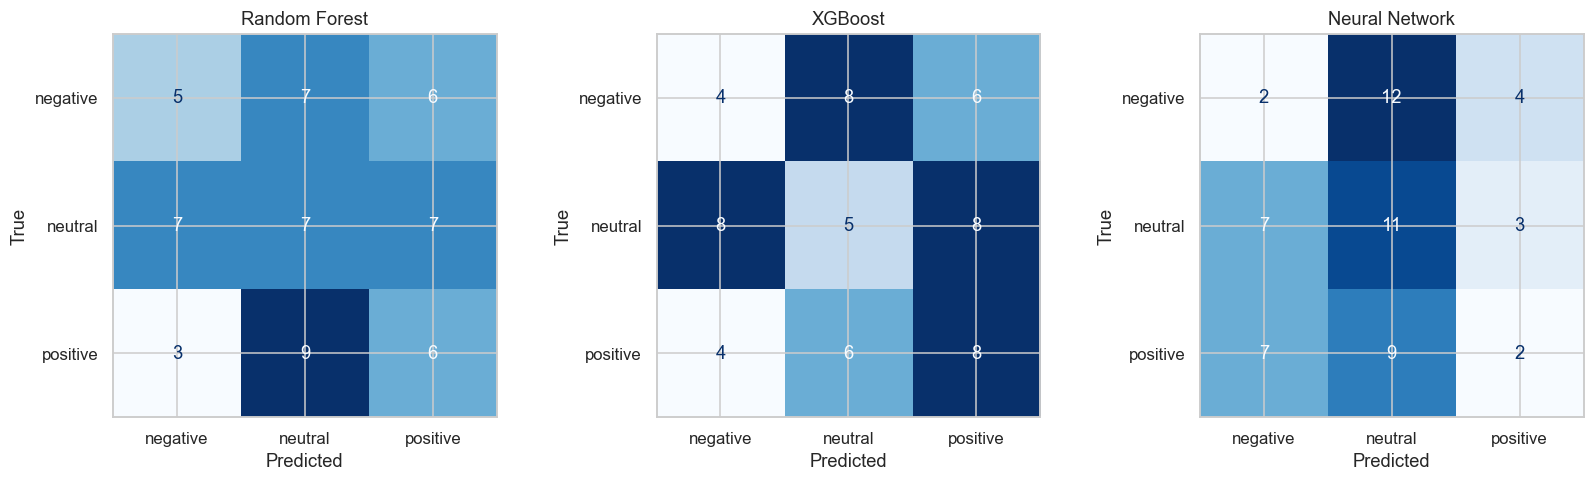

In [14]:
models_for_cm = [("Random Forest", test_preds.get("RandomForest"))]
if "XGBoost" in test_preds:
    models_for_cm.append(("XGBoost", test_preds["XGBoost"]))
models_for_cm.append(("Neural Network", test_preds.get("NeuralNet")))
models_for_cm = [(n, p) for n, p in models_for_cm if p is not None]

fig, axes = plt.subplots(1, len(models_for_cm),
                         figsize=(5 * len(models_for_cm), 4.5))
if len(models_for_cm) == 1:
    axes = [axes]
for ax, (name, y_pred) in zip(axes, models_for_cm):
    cm = confusion_matrix(y_test_enc, y_pred, labels=list(range(len(classes))))
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout(); plt.show()


## 14  ROC Curves (one-vs-rest)

Because `valence_direction` has 3 classes, we draw **one-vs-rest**
ROC curves: each class against the rest, plus the macro-average AUC per
model. The diagonal is chance. A curve hugging the top-left corner indicates
strong separability.


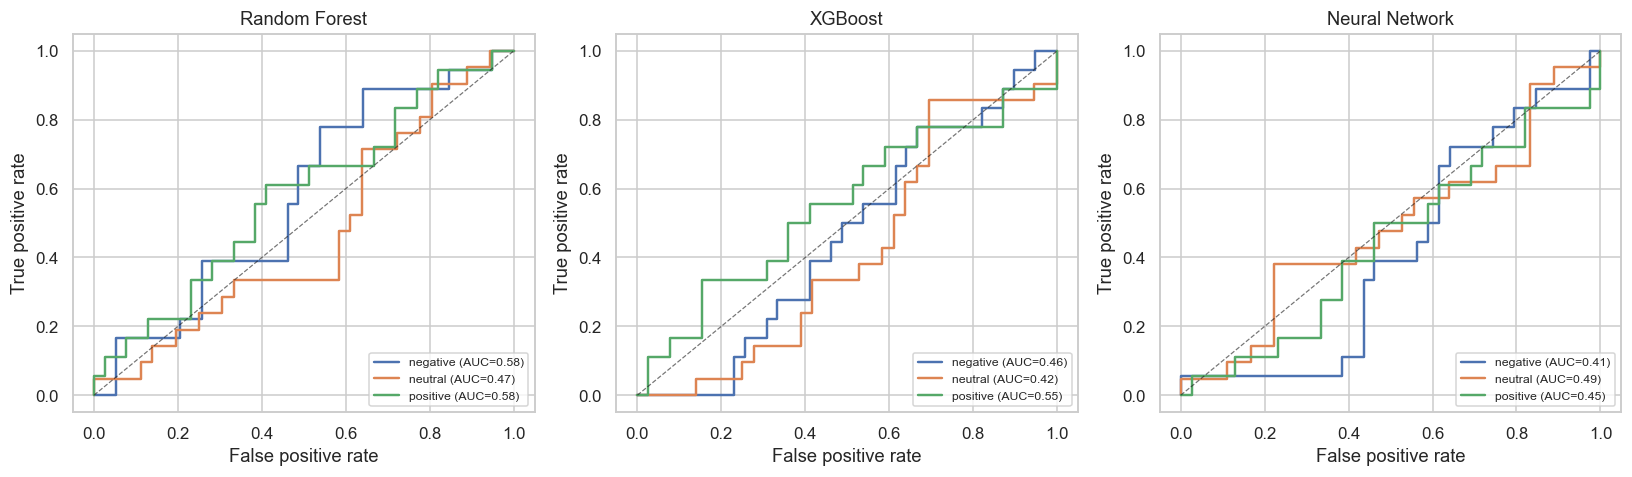

In [15]:
def plot_roc_ovr(model, X_te, y_te_enc, name, ax):
    try:
        y_proba = model.predict_proba(X_te)
    except Exception:
        ax.set_title(f"{name}: no probabilities"); return
    y_bin = label_binarize(y_te_enc, classes=list(range(len(classes))))
    if y_bin.shape[1] == 1:
        y_bin = np.hstack([1 - y_bin, y_bin])
    for i, cls in enumerate(classes):
        if y_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        auc_i = roc_auc_score(y_bin[:, i], y_proba[:, i])
        ax.plot(fpr, tpr, lw=1.6, label=f"{cls} (AUC={auc_i:.2f})")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.6)
    ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
    ax.set_title(name); ax.legend(fontsize=8, loc="lower right")

panels = [("Random Forest", rf_best, S["X_test"])]
if xgb_best is not None:
    panels.append(("XGBoost", xgb_best, S["X_test"]))
panels.append(("Neural Network", mlp_best, X_test_scaled))

fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 4.5))
if len(panels) == 1: axes = [axes]
for ax, (name, model, Xte) in zip(axes, panels):
    plot_roc_ovr(model, Xte, y_test_enc, name, ax)
plt.tight_layout(); plt.show()


## 15  Feature Importance

Tree models expose impurity-based feature importances, which tell us **which
plant-signal characteristics drive the valence prediction**. (The MLP
has no direct equivalent.) We plot the importances of the best tree model.


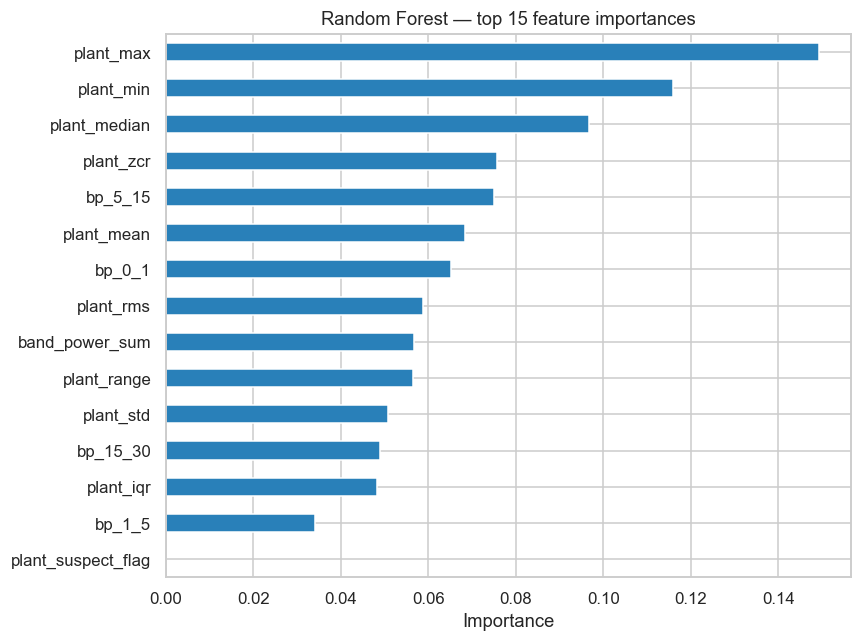

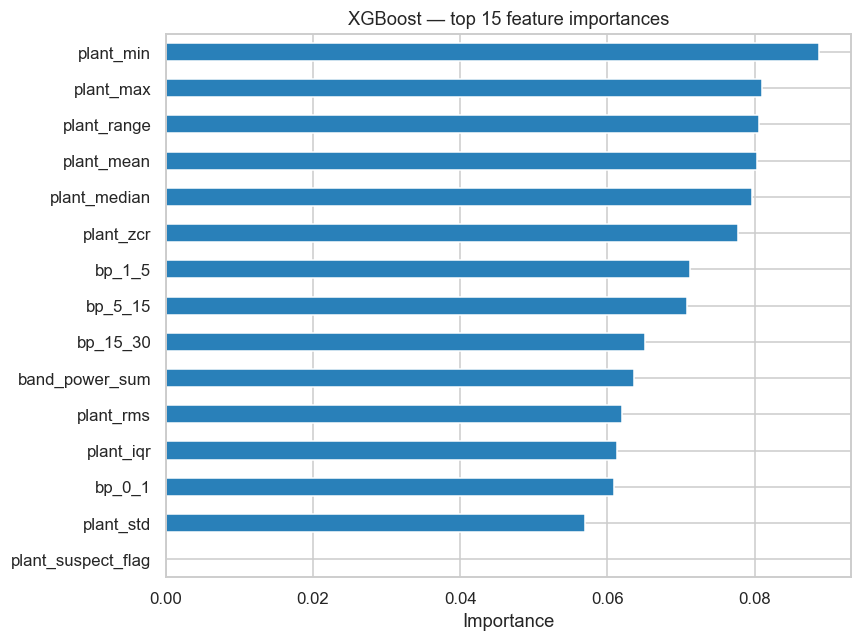

In [16]:
def plot_importance(model, feature_names, name, top_n=15):
    if not hasattr(model, "feature_importances_"):
        print(f"{name} has no feature_importances_."); return None
    imp = pd.Series(model.feature_importances_, index=feature_names)
    imp = imp.sort_values(ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(imp))))
    imp[::-1].plot.barh(ax=ax, color="#2980b9")
    ax.set_title(f"{name} — top {len(imp)} feature importances")
    ax.set_xlabel("Importance")
    plt.tight_layout(); plt.show()
    return imp

rf_imp = plot_importance(rf_best, X.columns, "Random Forest")
if xgb_best is not None:
    xgb_imp = plot_importance(xgb_best, X.columns, "XGBoost")


## 16  Final Model Comparison

We collect the test-set metrics of all three models side by side and pick the
best by **macro-F1** (the fairest single number for an imbalanced multi-class
problem).


Test-set comparison (sorted by macro-F1):

              accuracy  f1_macro  roc_auc
RandomForest     0.316     0.315    0.539
XGBoost          0.298     0.295    0.475
NeuralNet        0.263     0.227    0.448

* Best-performing model: RandomForest


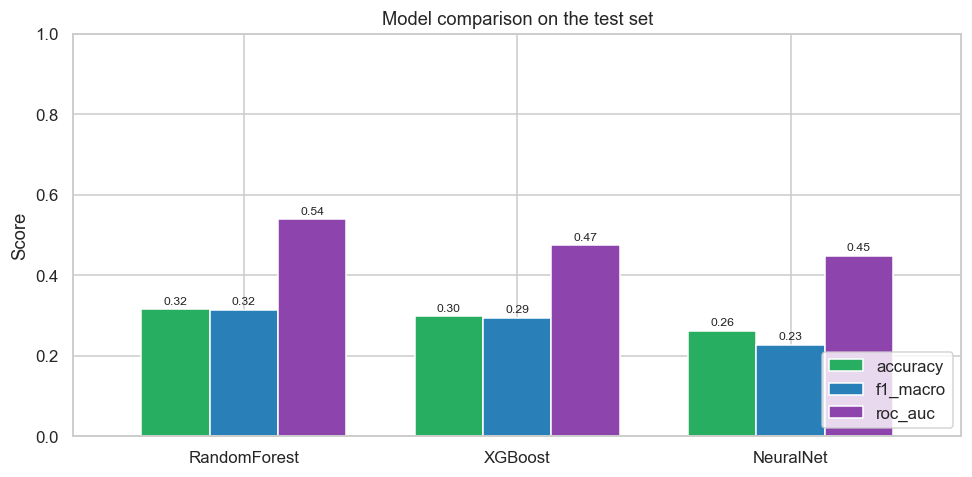

In [17]:
cmp = pd.DataFrame(test_results).T[["accuracy", "f1_macro", "roc_auc"]].round(3)
cmp = cmp.sort_values("f1_macro", ascending=False)
print("Test-set comparison (sorted by macro-F1):\n")
print(cmp.to_string())

best_overall = cmp.index[0]
print(f"\n* Best-performing model: {best_overall}")

# Bar chart of the three metrics
ax = cmp.plot.bar(figsize=(9, 4.5), rot=0, width=0.75,
                  color=["#27ae60", "#2980b9", "#8e44ad"])
ax.set_title("Model comparison on the test set")
ax.set_ylabel("Score"); ax.set_ylim(0, 1)
ax.legend(loc="lower right")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=8, padding=2)
plt.tight_layout(); plt.show()


## 17  Persist the Best Model

The winner from Section 16 (highest macro-F1 on the test set) is saved to
disk as a `.pkl` file in `../models/`, named `<model_type>_<label_type>.pkl`
(e.g. `random_forest_valence.pkl`) — so it can be reloaded later without
repeating the search/training above.

Each model was fit on **`y_train_enc`** (the integer-encoded target), so a
raw pickle of the estimator alone loses the mapping back to the original
class strings. The pickle is therefore a small bundle
`{"model", "classes", "label_type", "model_type"}`, where `classes[i]` is the
string label for encoded class `i` (exactly the `classes` list used to build
`class_to_int` in Section 6) — this is what a consumer needs to turn
`model.predict(...)` back into `"positive"` / `"neutral"` / `"negative"`.

The neural network was tuned on **scaled** features, so if it wins it is
bundled together with its fitted `StandardScaler` in an `sklearn` `Pipeline`
before saving, so the persisted file accepts raw feature values just like the
tree models do.


In [18]:
import pickle
from sklearn.pipeline import Pipeline

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

LABEL_TYPE = "valence"   # this notebook's target: the `valence_direction` axis
MODEL_SLUG = {"RandomForest": "random_forest", "XGBoost": "xgboost", "NeuralNet": "neural_network"}

fitted_models = {"RandomForest": rf_best, "NeuralNet": mlp_best}
if xgb_best is not None:
    fitted_models["XGBoost"] = xgb_best

best_estimator = fitted_models[best_overall]

# The MLP was tuned on scaled features - bundle the fitted scaler in front of
# it so the persisted model accepts raw feature values, same as the tree models.
if best_overall == "NeuralNet":
    best_estimator = Pipeline([("scaler", scaler), ("model", best_estimator)])

# classes[i] recovers the string label for encoded class i (see Section 6) -
# every model here was fit on y_train_enc, not the original strings, so this
# mapping must travel with the pickle or predictions are meaningless integers.
bundle = {
    "model": best_estimator,
    "classes": list(classes),
    "label_type": LABEL_TYPE,
    "model_type": best_overall,
}

model_path = MODELS_DIR / f"{MODEL_SLUG[best_overall]}_{LABEL_TYPE}.pkl"
with open(model_path, "wb") as f:
    pickle.dump(bundle, f)

print(f"Persisted best model ({best_overall}, test macro-F1={cmp.loc[best_overall, 'f1_macro']:.3f}) "
      f"to: {model_path.resolve()}")
print(f"Classes: {bundle['classes']}")


Persisted best model (RandomForest, test macro-F1=0.315) to: C:\Uni Koeln\COIN_Project\COIN2026_Team-1_Plant-Emotion-Detector\models\random_forest_valence.pkl
Classes: ['negative', 'neutral', 'positive']


## 18  Discussion, Conclusions & Future Work

### Which model performed best, and why
The comparison above selects the winner by macro-F1. In small tabular
problems like this one, **gradient-boosted trees (XGBoost)** and **Random
Forest** typically outperform a neural network, because:
- tree ensembles handle modest sample sizes and mixed feature scales gracefully,
- they need little data to find threshold-style rules in the spectral band
  powers,
- a neural network usually needs more data than a pilot cohort provides and is
  more prone to over-fitting here (mitigated, not eliminated, by early stopping).

### Which features contributed most
Read this off the feature-importance plot (Section 15). `valence_direction` is derived purely from facial expression (§4.6-4.8 of the labelling notebook), which has no known causal link to the plant's bioelectric signal, so we do not expect a strong physiological reason for any one plant feature to dominate here — a flat or noisy importance profile would itself be an informative (negative) result.

### Honest limitations
- **Sample size.** With a pilot cohort the absolute scores carry wide
  confidence intervals; treat them as relative comparisons, not final accuracy.
- **Label provenance.** The target is a proxy label read **only** from facial expression (HSEmotion `enet_b0_8_va_mtl`) — see the labelling notebook's §4.13 for why this is not ground truth (no self-report, an imperfect direction estimator, and a participant who feels something without showing it is labelled `neutral`).
- **No `label_confidence` covariate.** Unlike `04_ml_pipeline_emotion.ipynb`,
  this notebook does not use `label_confidence` as a feature, because it is
  computed from the clarity of *both* axes (§4.8 of the labelling notebook)
  and would leak information about `valence_direction` itself.
- **Sample-rate caveat.** Spectral band edges assume the true measured plant
  sampling rate (§4.11 of the labelling notebook); if firmware timing
  changes, recompute the band powers.

### Future work
- Collect the full 10–15 participant cohort and re-run — the pipeline already
  scales without changes.
- Add engineered features straight from the raw `events.jsonl` plant stream
  (Hjorth parameters, spectral entropy, wavelet energy) beyond the summary
  features stored per window.
- Use **nested** cross-validation for an unbiased performance estimate once more
  data is available.
- Compare this notebook's results directly against
  `04_ml_pipeline_emotion.ipynb` and its arousal/valence sibling notebook —
  since all three targets are derived from the same windows, differences in
  achievable accuracy are informative about which axis the plant signal
  tracks better.

---

*End of pipeline. The consolidated dataset and the three ML-pipeline
notebooks (crossed emotion, valence, arousal) form a reproducible path from
raw multi-session recordings to a compared set of classifiers per label
axis.*
